<a href="https://colab.research.google.com/github/Foll0wTh3Wh1teRabbit/ML/blob/master/NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Наи́вный ба́йесовский классифика́тор — простой вероятностный классификатор, основанный на применении теоремы Байеса со строгими (наивными) предположениями о независимости.

В зависимости от точной природы вероятностной модели, наивные байесовские классификаторы могут обучаться очень эффективно. Во многих практических приложениях для оценки параметров для наивных байесовых моделей используют метод максимального правдоподобия; другими словами, можно работать с наивной байесовской моделью, не веря в байесовскую вероятность и не используя байесовские методы.

Несмотря на наивный вид и, несомненно, очень упрощенные условия, наивные байесовские классификаторы часто работают намного лучше нейронных сетей во многих сложных жизненных ситуациях.

Достоинством наивного байесовского классификатора является малое количество данных, необходимых для обучения, оценки параметров и классификации.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, mean_absolute_error, mean_squared_error

In [ ]:
people = load_breast_cancer()

df = pd.DataFrame(people.data, columns = people.feature_names)
df["target"] = people.target

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [ ]:
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

Видов Байесовского классификатора - множество.  
Рассмотрим Гауссовский наивный Байесовский классификатор.

In [ ]:
gnb = GaussianNB().fit(X_train, y_train)

y_pred = gnb.predict(X_test)

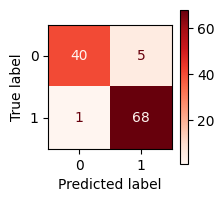

In [ ]:
cf_mat = confusion_matrix(y_test, y_pred)

cm_fig, cm_ax = plt.subplots(figsize=(2, 2))
cf_mat_disp = ConfusionMatrixDisplay(cf_mat)
cf_mat_disp.plot(ax=cm_ax, cmap=plt.cm.Reds)

plt.show()

In [ ]:
print("Accuracy, Gaussian:", accuracy_score(y_test, y_pred))
print("Precision, Gaussian:", precision_score(y_test, y_pred, average='macro'))
print("Recall, Gaussian:", recall_score(y_test, y_pred, average='macro'))

Accuracy, Gaussian: 0.9473684210526315
Precision, Gaussian: 0.9535583027063147
Recall, Gaussian: 0.9371980676328502


Предполагается, что объекты обучающей выборки распределены по Гауссу, а параметры распределения определяются по мере обучения согласно принципу максимального правдоподобия.  
Получили весьма неплохие показатели!  
Попробуем использовать мультиномиальный наивный Байесовский классификатор.

In [ ]:
cnb = MultinomialNB().fit(X_train, y_train)

y_pred = cnb.predict(X_test)

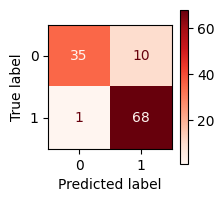

In [ ]:
cf_mat = confusion_matrix(y_test, y_pred)

cm_fig, cm_ax = plt.subplots(figsize=(2, 2))
cf_mat_disp = ConfusionMatrixDisplay(cf_mat)
cf_mat_disp.plot(ax=cm_ax, cmap=plt.cm.Reds)

plt.show()

In [ ]:
print("Accuracy, Multinomial:", accuracy_score(y_test, y_pred))
print("Precision, Multinomial:", precision_score(y_test, y_pred, average='macro'))
print("Recall, Multinomial:", recall_score(y_test, y_pred, average='macro'))

Accuracy, Multinomial: 0.9035087719298246
Precision, Multinomial: 0.9220085470085471
Recall, Multinomial: 0.8816425120772947


Данная модель опирается исключительно на эмпирический опыт: отсутствуют какие-либо предположения о характере распределения объектов выборки.